Assignment 1

Question 10

In [2]:
# Question 10

import numpy as np

# Monthly closing prices
prices = np.array([
    [100, 108, 103, 115, 110, 119, 125, 121, 130, 127, 135, 140],  # Stock A
    [200, 195, 210, 205, 220, 215, 225, 230, 222, 235, 240, 238]   # Stock B
])

# (a) Monthly simple returns using NumPy slicing
returns = (prices[:, 1:] - prices[:, :-1]) / prices[:, :-1]

print("Monthly Returns (2 x 11):")
print(returns)
print("Shape of returns:", returns.shape)

# (b) Annualised mean return
monthly_mean = np.mean(returns, axis=1)
annualised_mean = monthly_mean * 12

# Annualised standard deviation
monthly_std = np.std(returns, axis=1, ddof=1)
annualised_std = monthly_std * np.sqrt(12)

print("\nAnnualised Mean Returns:")
print(annualised_mean)

print("\nAnnualised Standard Deviations:")
print(annualised_std)

# (c) Covariance matrix
cov_matrix = np.cov(returns)

print("\nCovariance Matrix:")
print(cov_matrix)

# Correlation coefficient
rho = np.corrcoef(returns)[0, 1]

# Verify covariance = rho * sigmaA * sigmaB
sigma_A = np.std(returns[0], ddof=1)
sigma_B = np.std(returns[1], ddof=1)

check_value = rho * sigma_A * sigma_B

print("\nOff-diagonal covariance value:")
print(cov_matrix[0, 1])

print("\nrho * sigma_A * sigma_B:")
print(check_value)

Monthly Returns (2 x 11):
[[ 0.08       -0.0462963   0.11650485 -0.04347826  0.08181818  0.05042017
  -0.032       0.07438017 -0.02307692  0.06299213  0.03703704]
 [-0.025       0.07692308 -0.02380952  0.07317073 -0.02272727  0.04651163
   0.02222222 -0.03478261  0.05855856  0.0212766  -0.00833333]]
Shape of returns: (2, 11)

Annualised Mean Returns:
[0.39087388 0.20073826]

Annualised Standard Deviations:
[0.20199403 0.14582022]

Covariance Matrix:
[[ 0.00340013 -0.00206426]
 [-0.00206426  0.00177196]]

Off-diagonal covariance value:
-0.0020642605060094284

rho * sigma_A * sigma_B:
-0.0020642605060094284


Question 11

In [3]:
# Question 11

import numpy as np

np.random.seed(42)

# (a) Define expected returns vector
mu = np.array([0.15, 0.08, 0.05])

# Covariance matrix from Q6
Sigma = np.array([
    [0.0625, 0.012, 0.001],
    [0.012, 0.0144, 0.00096],
    [0.001, 0.00096, 0.0016]
])

# Equal weight portfolio
w = np.array([1/3, 1/3, 1/3])

# Portfolio expected return
portfolio_return = w @ mu

# Portfolio variance
portfolio_variance = w @ Sigma @ w

print("Expected Portfolio Return:")
print(portfolio_return)

print("\nPortfolio Variance:")
print(portfolio_variance)

# Portfolio standard deviation
portfolio_std = np.sqrt(portfolio_variance)

print("\nPortfolio Standard Deviation:")
print(portfolio_std)

# (b) Generate 10,000 random weights
n_portfolios = 10000

weights = np.random.dirichlet(np.ones(3), n_portfolios)

# Portfolio returns
portfolio_returns = weights @ mu

# Portfolio variances
portfolio_variances = np.sum((weights @ Sigma) * weights, axis=1)

# Portfolio standard deviations
portfolio_std = np.sqrt(portfolio_variances)

print("\nShape of Portfolio Returns:")
print(portfolio_returns.shape)

print("Shape of Portfolio Standard Deviations:")
print(portfolio_std.shape)

# (c) Sharpe Ratio (Rf = 4%)
rf = 0.04

sharpe_ratios = (portfolio_returns - rf) / portfolio_std

# Maximum Sharpe Ratio
best_index = np.argmax(sharpe_ratios)

print("\nMaximum Sharpe Ratio:")
print(sharpe_ratios[best_index])

print("\nWeights of Maximum Sharpe Portfolio:")
print(weights[best_index])

print("\nReturn of Maximum Sharpe Portfolio:")
print(portfolio_returns[best_index])

print("\nVolatility of Maximum Sharpe Portfolio:")
print(portfolio_std[best_index])

Expected Portfolio Return:
0.09333333333333332

Portfolio Variance:
0.011824444444444443

Portfolio Standard Deviation:
0.10874026137748816

Shape of Portfolio Returns:
(10000,)
Shape of Portfolio Standard Deviations:
(10000,)

Maximum Sharpe Ratio:
0.5052923321966607

Weights of Maximum Sharpe Portfolio:
[0.20343152 0.17148749 0.62508099]

Return of Maximum Sharpe Portfolio:
0.07548777687863276

Volatility of Maximum Sharpe Portfolio:
0.07023216981020969


Question 12

In [4]:
# Question 12

import numpy as np

# Given values
mu1 = 0.12
sigma1 = 0.20

mu2 = 0.06
sigma2 = 0.10

w1 = 0.6
w2 = 0.4

# (a) Correlation values
rho = np.linspace(-1, 1, 200)

# Portfolio variance
portfolio_variance = (
    (w1**2) * (sigma1**2)
    + (w2**2) * (sigma2**2)
    + 2 * w1 * w2 * rho * sigma1 * sigma2
)

# Portfolio volatility
portfolio_sigma = np.sqrt(portfolio_variance)

print("Portfolio Volatility Shape:")
print(portfolio_sigma.shape)

# (b) Minimum volatility
min_index = np.argmin(portfolio_sigma)

min_rho = rho[min_index]
min_sigma = portfolio_sigma[min_index]

print("\nCorrelation at Minimum Risk:")
print(min_rho)

print("\nMinimum Portfolio Risk:")
print(min_sigma)

# (c)
print("\nAnalytical Verification:")
print("Minimum occurs at rho = -1 since portfolio variance is linear in rho and decreases as rho decreases.")

Portfolio Volatility Shape:
(200,)

Correlation at Minimum Risk:
-1.0

Minimum Portfolio Risk:
0.08000000000000002

Analytical Verification:
Minimum occurs at rho = -1 since portfolio variance is linear in rho and decreases as rho decreases.


Question 13

In [5]:
# Question 13

import pandas as pd
import numpy as np

# Given code
np.random.seed(0)

dates = pd.date_range('2023-01-02', periods=52, freq='W-MON')

mu_weekly = np.array([0.003, 0.002, 0.001, 0.0015])
sig_weekly = np.array([0.04, 0.03, 0.02, 0.025])

returns_sim = np.random.normal(mu_weekly, sig_weekly, (52, 4))

prices_sim = 100 * np.cumprod(1 + returns_sim, axis=0)

df = pd.DataFrame(
    prices_sim,
    index=dates,
    columns=['AAPL', 'MSFT', 'GOOGL', 'AMZN']
)

print("Simulated Prices:")
print(df.head())

# (a) Weekly returns
df_returns = df.pct_change().dropna()

print("\nFirst 3 Rows of Weekly Returns:")
print(df_returns.head(3))

print("\nShape of Returns DataFrame:")
print(df_returns.shape)

# (b) Describe statistics
description = df_returns.describe()

print("\nDescriptive Statistics:")
print(description)

highest_mean = df_returns.mean().idxmax()
highest_std = df_returns.std().idxmax()

print("\nAsset with Highest Mean Return:")
print(highest_mean)

print("\nAsset with Highest Standard Deviation:")
print(highest_std)

# (c) Annualised Sharpe Ratio
rf = 0.02  # annual risk-free rate

annual_return = df_returns.mean() * 52
annual_std = df_returns.std() * np.sqrt(52)

sharpe_ratio = (annual_return - rf) / annual_std

print("\nAnnualised Sharpe Ratios:")
print(sharpe_ratio)

Simulated Prices:
                  AAPL        MSFT       GOOGL        AMZN
2023-01-02  107.356209  101.400472  102.057476  105.752233
2023-01-09  115.698036   98.630379  104.098806  105.510702
2023-01-16  115.567441  100.042565  104.502800  109.505004
2023-01-23  119.432191  100.607830  105.535002  110.582737
2023-01-30  126.928133  100.189830  106.301329  108.387405

First 3 Rows of Weekly Returns:
                AAPL      MSFT     GOOGL      AMZN
2023-01-09  0.077702 -0.027318  0.020002 -0.002284
2023-01-16 -0.001129  0.014318  0.003881  0.037857
2023-01-23  0.033442  0.005650  0.009877  0.009842

Shape of Returns DataFrame:
(51, 4)

Descriptive Statistics:
            AAPL       MSFT      GOOGL       AMZN
count  51.000000  51.000000  51.000000  51.000000
mean    0.005603   0.002192  -0.000887   0.006094
std     0.045641   0.032819   0.017055   0.022948
min    -0.099120  -0.057424  -0.033125  -0.054085
25%    -0.030293  -0.025056  -0.013135  -0.006813
50%     0.001429  -0.002650  

Question 14

In [6]:
# Question 14

# (a) Correlation matrix
correlation_matrix = df_returns.corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Find lowest correlation pair
corr_unstacked = correlation_matrix.unstack()

# Remove self-correlations
corr_unstacked = corr_unstacked[
    corr_unstacked.index.get_level_values(0)
    != corr_unstacked.index.get_level_values(1)
]

lowest_pair = corr_unstacked.idxmin()
lowest_value = corr_unstacked.min()

print("\nLowest Correlation Pair:")
print(lowest_pair)

print("\nLowest Correlation Value:")
print(lowest_value)

# (b) Equal-weight portfolio return
weights = pd.Series(
    [0.25, 0.25, 0.25, 0.25],
    index=['AAPL', 'MSFT', 'GOOGL', 'AMZN']
)

portfolio_returns = df_returns.dot(weights)

print("\nPortfolio Returns:")
print(portfolio_returns.head())

# (c) Monthly returns using resample
monthly_returns = portfolio_returns.resample('ME').apply(
    lambda x: (1 + x).prod() - 1
)

print("\nMonthly Portfolio Returns:")
print(monthly_returns)

print("\nMean Monthly Return:")
print(monthly_returns.mean())

print("\nMonthly Standard Deviation:")
print(monthly_returns.std())

Correlation Matrix:
           AAPL      MSFT     GOOGL      AMZN
AAPL   1.000000 -0.075324  0.190733  0.060147
MSFT  -0.075324  1.000000  0.287278  0.069544
GOOGL  0.190733  0.287278  1.000000 -0.001252
AMZN   0.060147  0.069544 -0.001252  1.000000

Lowest Correlation Pair:
('AAPL', 'MSFT')

Lowest Correlation Value:
-0.07532396170747635

Portfolio Returns:
2023-01-09    0.017025
2023-01-16    0.013732
2023-01-23    0.014703
2023-01-30    0.011504
2023-02-06   -0.019069
Freq: W-MON, dtype: float64

Monthly Portfolio Returns:
2023-01-31    0.058185
2023-02-28    0.001390
2023-03-31   -0.022310
2023-04-30   -0.036822
2023-05-31    0.011764
2023-06-30    0.051925
2023-07-31    0.084694
2023-08-31    0.012007
2023-09-30    0.008753
2023-10-31    0.021548
2023-11-30   -0.049706
2023-12-31    0.026272
Freq: ME, dtype: float64

Mean Monthly Return:
0.013974973306651484

Monthly Standard Deviation:
0.039023369077949295


Question 15

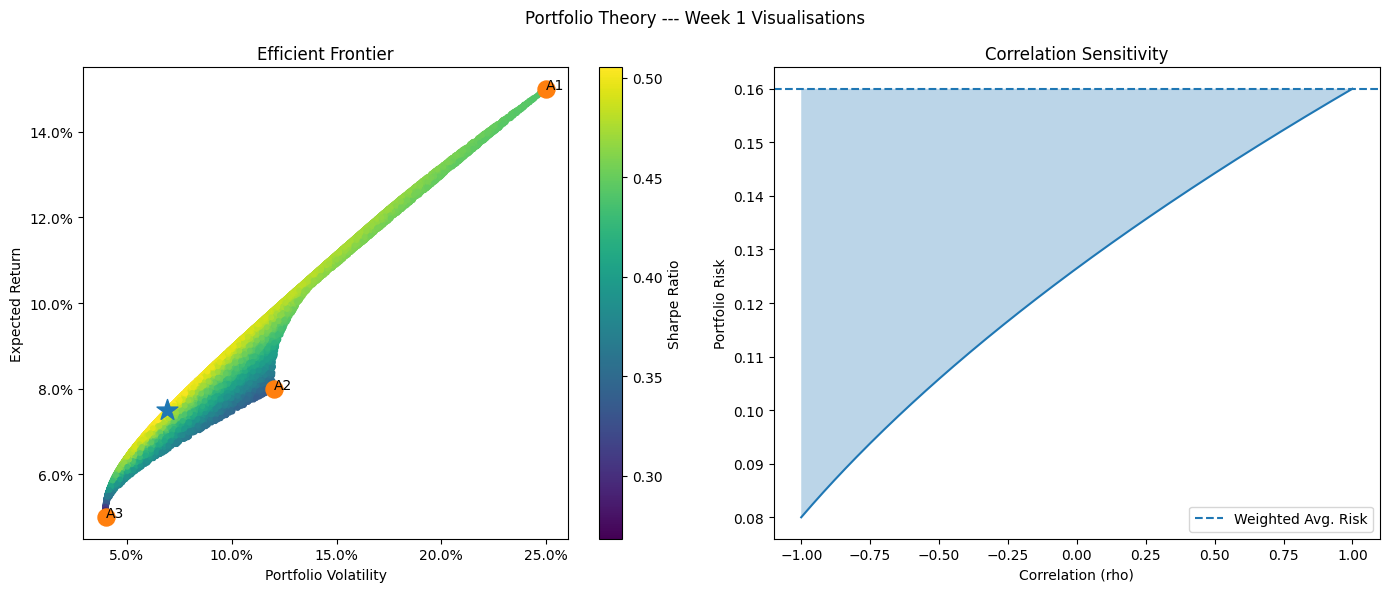

In [7]:
# Question 15

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

np.random.seed(42)

# --------------------------
# 3-asset universe (Q11)
# --------------------------

mu = np.array([0.15, 0.08, 0.05])

Sigma = np.array([
    [0.0625, 0.012, 0.001],
    [0.012, 0.0144, 0.00096],
    [0.001, 0.00096, 0.0016]
])

rf = 0.04

# Simulate 20,000 portfolios
n_portfolios = 20000

weights = np.random.dirichlet(np.ones(3), n_portfolios)

portfolio_returns = weights @ mu

portfolio_variances = np.sum((weights @ Sigma) * weights, axis=1)

portfolio_volatility = np.sqrt(portfolio_variances)

sharpe_ratios = (
    portfolio_returns - rf
) / portfolio_volatility

# Maximum Sharpe portfolio
best_index = np.argmax(sharpe_ratios)

# --------------------------
# Correlation sensitivity
# --------------------------

sigma1 = 0.20
sigma2 = 0.10

w1 = 0.6
w2 = 0.4

rho = np.linspace(-1, 1, 200)

sigma_p = np.sqrt(
    (w1**2) * (sigma1**2)
    + (w2**2) * (sigma2**2)
    + 2 * w1 * w2 * rho * sigma1 * sigma2
)

weighted_avg_risk = (
    w1 * sigma1
    + w2 * sigma2
)

# --------------------------
# Plotting
# --------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

# Left subplot
scatter = axes[0].scatter(
    portfolio_volatility,
    portfolio_returns,
    c=sharpe_ratios,
    cmap='viridis',
    s=10
)

axes[0].scatter(
    portfolio_volatility[best_index],
    portfolio_returns[best_index],
    marker='*',
    s=250
)

asset_vol = np.sqrt(np.diag(Sigma))
asset_return = mu
tickers = ['A1', 'A2', 'A3']

axes[0].scatter(
    asset_vol,
    asset_return,
    s=150
)

for i, ticker in enumerate(tickers):
    axes[0].annotate(
        ticker,
        (asset_vol[i], asset_return[i])
    )

axes[0].set_title('Efficient Frontier')
axes[0].set_xlabel('Portfolio Volatility')
axes[0].set_ylabel('Expected Return')

axes[0].xaxis.set_major_formatter(
    PercentFormatter(1)
)

axes[0].yaxis.set_major_formatter(
    PercentFormatter(1)
)

cbar = fig.colorbar(
    scatter,
    ax=axes[0]
)

cbar.set_label('Sharpe Ratio')

# Right subplot
axes[1].plot(rho, sigma_p)

axes[1].axhline(
    weighted_avg_risk,
    linestyle='--',
    label='Weighted Avg. Risk'
)

axes[1].fill_between(
    rho,
    sigma_p,
    weighted_avg_risk,
    where=(sigma_p < weighted_avg_risk),
    alpha=0.3
)

axes[1].set_title(
    'Correlation Sensitivity'
)

axes[1].set_xlabel('Correlation (rho)')
axes[1].set_ylabel('Portfolio Risk')

axes[1].legend()

# Global title
fig.suptitle(
    'Portfolio Theory --- Week 1 Visualisations'
)

plt.tight_layout()

plt.savefig(
    'week1_plots.png',
    dpi=150
)

plt.show()